In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import DDPG
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.vec_env import DummyVecEnv


In [ ]:

# ------------------ POTENCIAL ------------------
def potencial(x, y):
    return np.exp(-((x-0.5)**2 + (y-0.7)**2)/3)


class ParticlePotentialEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(self,
                 potential_fn=None,
                 max_steps=1000,
                 dt=0.02,
                 speed=0.25,
                 goal_radius=0.02,
                 render_mode=None):

        super().__init__()

        self.potential_fn = potential_fn or potencial
        self.max_steps = max_steps
        self.dt = dt
        self.speed = speed
        self.goal_radius = goal_radius
        self.render_mode = render_mode

        # ✅ Acción normalizada (clave para DDPG)
        self.action_space = spaces.Box(
            low=-1.0,
            high=1.0,
            shape=(1,),
            dtype=np.float32
        )

        # ✅ Observación acotada
        self.observation_space = spaces.Box(
            low=np.array([0, 0, -1, -1], dtype=np.float32),
            high=np.array([1, 1, 1, 1], dtype=np.float32),
            dtype=np.float32
        )

        self.pos = None
        self.goal = None
        self.steps = 0

    def _obs(self):
        return np.concatenate([self.pos, self.goal - self.pos]).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # ✅ usar self.np_random (importante)
        self.pos = self.np_random.uniform(0, 1, size=2).astype(np.float32)
        self.goal = self.np_random.uniform(0, 1, size=2).astype(np.float32)

        self.steps = 0
        self.traj = [self.pos.copy()]

        return self._obs(), {}

    def step(self, action):
      action = np.clip(action, -1, 1)
      theta = float(action[0] * np.pi)

      prev_pos = self.pos.copy()

      direction = np.array([np.cos(theta), np.sin(theta)], dtype=np.float32)
      self.pos += self.speed * direction * self.dt

      self.steps += 1
      self.traj.append(self.pos.copy())

      # ---- métricas ----
      vec_to_goal = self.goal - self.pos
      dist = np.linalg.norm(vec_to_goal)
      prev_dist = np.linalg.norm(self.goal - prev_pos)

      V = self.potential_fn(*self.pos)

      # ---- reward ----
      # 1. Progreso real
      r_progress = (prev_dist - dist)

      # 2. Dirección correcta 
      if np.linalg.norm(vec_to_goal) > 1e-8:
          dir_to_goal = vec_to_goal / np.linalg.norm(vec_to_goal)
          r_align = np.dot(direction, dir_to_goal)
      else:
          r_align = 0.0

      # 3. Penalización potencial
      r_potential = -0.3 * V

      # 4. Penalización por moverse 
      r_step = -0.01

      reward = (
          3.0 * r_progress +
          0.5 * r_align +
          r_potential +
          r_step
      )

      terminated = dist < self.goal_radius
      if terminated:
          reward += 20.0

      out = np.any((self.pos < 0.0) | (self.pos > 1.0))
      if out:
          reward -= 20.0

      truncated = self.steps >= self.max_steps or out

      info = {"distance": dist}

      return self._obs(), reward, terminated, truncated, info

    def render(self):
        if not hasattr(self, "fig"):
            self.fig, self.ax = plt.subplots()
            plt.ion()

        self.ax.clear()
        t = np.array(self.traj)

        if len(t) > 1:
            self.ax.plot(t[:, 0], t[:, 1], "c-")

        self.ax.plot(*self.goal, "b*")
        self.ax.plot(*self.pos, "ro")

        self.ax.set_xlim(0, 1)
        self.ax.set_ylim(0, 1)
        self.ax.set_title(f"step {self.steps}")

        plt.pause(0.001)

In [ ]:


# ---- entorno ----
def make_env():
    return ParticlePotentialEnv()

env = DummyVecEnv([make_env])


# ---- ruido (MUY IMPORTANTE en DDPG) ----
n_actions = env.action_space.shape[-1]
action_noise = NormalActionNoise(
    mean=np.zeros(n_actions),
    sigma=0.2 * np.ones(n_actions)
)

# ---- modelo ----
model = DDPG(
    "MlpPolicy",
    env,
    learning_rate=1e-3,
    buffer_size=100_000,
    learning_starts=1000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    action_noise=action_noise,
    train_freq=(1, "step"),
    gradient_steps=1,
    verbose=1,
)

# ---- entrenamiento ----
model.learn(total_timesteps=100_000)

# ---- guardar ----
model.save("ddpg_part_pl")

Using cuda device
---------------------------------
| time/              |          |
|    episodes        | 4        |
|    fps             | 296      |
|    time_elapsed    | 5        |
|    total_timesteps | 1703     |
| train/             |          |
|    actor_loss      | -0.416   |
|    critic_loss     | 0.0212   |
|    learning_rate   | 0.001    |
|    n_updates       | 702      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 8        |
|    fps             | 169      |
|    time_elapsed    | 25       |
|    total_timesteps | 4375     |
| train/             |          |
|    actor_loss      | -2.63    |
|    critic_loss     | 0.0236   |
|    learning_rate   | 0.001    |
|    n_updates       | 3374     |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 12       |
|    fps             | 161      |
|    time_elapsed    | 33     

AttributeError: 'DummyVecEnv' object has no attribute 'save'

In [7]:

model = DDPG.load("ddpg_part")


env = ParticlePotentialEnv()

obs, _ = env.reset()

# ---- fijar estado manualmente ----
env.goal = np.array([0.0, 0.0], dtype=np.float32)
env.pos = np.array([1.0, 1.0], dtype=np.float32)

obs = np.concatenate([env.pos, env.goal - env.pos])

trajectory = [env.pos.copy()]

for _ in range(300):
    action, _ = model.predict(obs, deterministic=True)

    obs, reward, terminated, truncated, _ = env.step(action)
    trajectory.append(env.pos.copy())

    if terminated or truncated:
        break

trajectory = np.array(trajectory)

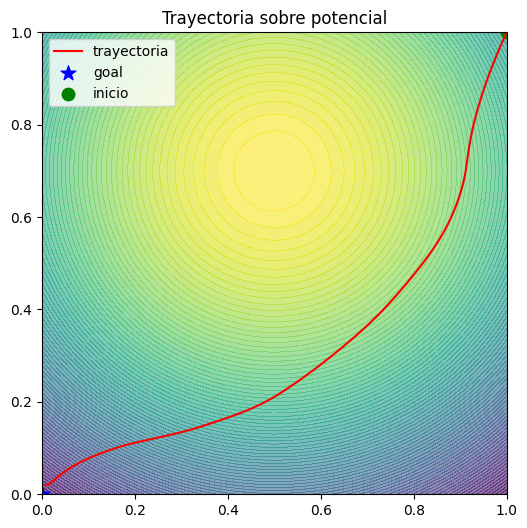

In [8]:
# ---- potencial ----
x = np.linspace(0, 1, 100)
y = np.linspace(0, 1, 100)
X, Y = np.meshgrid(x, y)
Z = np.exp(-((X-0.5)**2 + (Y-0.7)**2)/3)

plt.figure(figsize=(6,6))

# fondo: potencial
plt.contourf(X, Y, Z, levels=100, alpha=0.6)

# trayectoria
plt.plot(trajectory[:,0], trajectory[:,1], 'r-', label="trayectoria")

# puntos clave
plt.scatter(*env.goal, c='blue', marker='*', s=120, label="goal")
plt.scatter(*trajectory[0], c='green', s=80, label="inicio")

plt.xlim(0,1)
plt.ylim(0,1)
plt.title("Trayectoria sobre potencial")
plt.legend()

plt.show()